# Clump Finding

`clumpfind` locates **connected over-dense structures** and returns a per-clump catalog. It works
two ways:

* **3D** — friends-of-friends on the cells (hydro) or particles above a field threshold.
* **2D** — connected-component labelling of a [`projection`](@ref) map above a threshold.

Both return a [`ClumpCatalog`](@ref) sorted most-massive-first.

!!! tip "Try it on known ground truth"
    The [synthetic, data-free example](clumpfind_synthetic.md) builds a Mera object whose
    clumps are known exactly and scores every finder and feature against it (downloadable
    dataset included) — the quickest way to see the behaviour and accuracy of each algorithm.

The 3D finder runs on a pluggable framework: an [`AbstractFinder`](@ref) value (one of seven —
[`ThresholdFoF`](@ref), [`DensityWatershed`](@ref), [`Dendrogram`](@ref), [`GraphSegFinder`](@ref),
[`HDBSCANFinder`](@ref), [`PhaseSpaceFoF`](@ref), [`PersistenceFinder`](@ref)) selects the algorithm,
while a shared neighbour index, statistics, boundedness and catalog pipeline serves them all. The keyword form
`clumpfind(obj, field; …)` shown throughout this page is a convenience shim that builds a
`ThresholdFoF` for you, so existing scripts are unchanged; pass a finder explicitly to pick the
algorithm:

```julia
cat   = clumpfind(gas, ThresholdFoF(:rho; threshold=1e2, threshold_unit=:nH, linking_length=0.2))
cores = clumpfind(gas, DensityWatershed(:rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4))
```

## Choosing a finder

Seven [`AbstractFinder`](@ref) algorithms plug into the same neighbour-index / statistics / boundedness
/ catalog pipeline, so they share keywords and outputs and differ only in *how* cells are grouped.
Start with [`ThresholdFoF`](@ref); reach for the others when its single threshold isn't enough.

| Finder | Method | Reach for it when |
|---|---|---|
| [`ThresholdFoF`](@ref) | Friends-of-friends above a field threshold (Davis et al. 1985) | The default — fast, robust; isolated clumps over a clear background |
| [`DensityWatershed`](@ref) | FoF connectivity, then watershed split at saddles (DENMAX/SUBFIND); `persistence` prunes shallow basins | Deblending **touching/overlapping** peaks inside one connected over-dense region |
| [`Dendrogram`](@ref) | Multi-scale hierarchy (Rosolowsky & Leroy 2008); `min_delta` peak-to-saddle contrast | You want the **nested hierarchy** (leaves → branches → roots), not a flat catalog |
| [`GraphSegFinder`](@ref) | Graph segmentation by internal-vs-boundary contrast (Felzenszwalb & Huttenlocher 2004) | Density varies smoothly and no single threshold separates structures |
| [`HDBSCANFinder`](@ref) | Density-based hierarchical clustering, stable-cluster extraction | Clumps span a **wide density range** / variable background; you'd rather not pick a threshold |
| [`PhaseSpaceFoF`](@ref) | 6-D position+velocity FoF (Rockstar-style; Behroozi et al. 2013) | **Kinematically** separating spatially-overlapping structures (streams, mergers, substructure) |
| [`PersistenceFinder`](@ref) | Topological persistence / ToMATo (Chazal et al. 2013) | **Crowded** fields — rank peaks by prominence, robust to noise |

All take the same shared keywords (`field`, `threshold`, `linking_length`, `backend`, gravitational
boundedness, tidal truncation, …); see the **Density-adaptive finders** and **Phase-space & topology**
sections below for the algorithm-specific parameters.

!!! tip "Plotting the mass function"
    [`massfunctionplot`](@ref) draws the clump mass function straight from a
    [`ClumpCatalog`](@ref) — cumulative or differential — with a Makie backend loaded:

    ```julia
    using CairoMakie
    massfunctionplot(cat; cumulative=true)
    ```


## 3D — cells or particles (friends-of-friends)

Cells/particles with `field ≥ threshold` are linked into a clump when they lie within
`linking_length` (in `pos_unit`) of one another:

In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera
info = getinfo(400, joinpath(MERA_EXAMPLES, "RAMSES/manu_sim_sf_L14"))
# cap the refinement (lmax=10) and load only the central box, so the finders run in seconds
gas  = gethydro(info; lmax=10, xrange=[-5,5], yrange=[-5,5], zrange=[-5,5],
                center=[:bc], range_unit=:kpc);
println("cells loaded : ", length(gas.data))
println("box length   : ", gas.boxlen, " kpc")


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0

[Mera]: 2026-08-03T11:31:57.365



Code: RAMSES
output [400] summary:
mtime: 

2018-09-05T09:51:55
ctime: 2025-06-29T20:06:45.267
simulation time: 594.98 [Myr]
boxlen: 48.0 [kpc]
ncpu: 2048
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level(s): 6 - 14 --> cellsize(s): 750.0 [pc] - 2.93 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  

7  --> (:rho, :vx, :vy, :vz, :p, :passive_scalar_1, :passive_scalar_2)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :thermal_pressure, :passive_scalar_1, :passive_scalar_2)
γ: 1.6667
-------------------------------------------------------
gravity:       true
gravity-variables: (:epot, :ax, :ay, :az)
-------------------------------------------------------
particles:     true
- Npart:    5.091500e+05 
- Nstars:   5.066030e+05 


...

Final data size: 1277874 cells, 7 variables
Creating Table from 1277874 cells with max 4 threads...


  Threading: 4 threads for 11 columns


  Max threads requested: 4
  Available threads: 4
  Using parallel processing with 4 threads
  Creating IndexedTable with 11 columns...
✓ Table created in 2.605 seconds


Memory used for data table :107.2445936203003

 MB
-------------------------------------------------------

cells loaded : 1277874
box length   : 48.0 kpc


Select cells above 100 cm⁻³, link within 0.2 kpc, and keep clumps with ≥ 5 cells:

In [2]:
cat = clumpfind(gas, :rho;
                threshold=1e2, threshold_unit=:nH,   # select cells above 100 cm^-3
                linking_length=0.2, pos_unit=:kpc,    # link within 0.2 kpc
                mass_unit=:Msol, min_members=5)       # keep clumps with >= 5 cells

println("number of clumps : ", length(cat))
println()
println(cat)                       # ClumpCatalog summary

number of clumps : 34

ClumpCatalog: 34 clumps  [3D, field=rho ≥ 100.0 nH]


  mass Msol: total 6.712e9  max 2.034e9  median 4.058e7
  largest: 487 members, mass 2.034e9



In [3]:
# the most massive clump is a NamedTuple
c1 = cat[1]
println("largest clump:")
@show c1.id
@show c1.n_members
@show c1.mass
@show c1.com
@show c1.peak
@show c1.radius

largest clump:
c1.id = 1


c1.n_members = 487
c1.mass = 2.0337645080962305e9
c1.com = (22.061102887532154, 24.038745759498653, 24.05425590948421)
c1.peak = 86745.10109055592
c1.radius = 0.9229258020368907


0.9229258020368907

With a Makie backend loaded, [`clumpplot`](@ref) draws the catalog directly — each clump's centre of
mass as a marker sized by mass (and coloured by log mass), optionally over a projection background:

```julia
using CairoMakie
bg  = projection(gas, :sd, :Msol_pc2; center=[:bc])
fig = clumpplot(cat; background=bg)        # marker size ∝ mass, colour = log₁₀ mass
```

![Clumps found by `clumpfind` ([`clumpplot`](@ref): marker size ∝ mass, colour = log₁₀ mass) overlaid on
the gas surface density Σ. The markers sit on the over-dense peaks above the density threshold; fainter
arm and inter-arm gas *below* the threshold is intentionally not flagged — clump finding is always
threshold- (and finder-) dependent.](assets/features/clump_catalog.png)

!!! note "Not every visible peak is a clump — by design"
    A clump is what the finder + threshold define. Two effects are worth knowing:

    * **Threshold selection.** Peaks fainter than `threshold` are not selected at all, and a single
      friends-of-friends threshold can *merge* a whole connected over-dense region (e.g. the dense disk)
      into one clump while leaving fainter arms out. To separate touching peaks, use
      [`DensityWatershed`](@ref) (split at saddles, with `persistence` to prune shallow basins) rather
      than a higher [`ThresholdFoF`](@ref) threshold.
    * **Boundedness.** Detected over-densities are not necessarily self-gravitating. Add
      `boundedness=true` to get each clump's virial ratio `alpha_vir = 2·e_kin/|e_grav|` and a `bound`
      flag, and `bound_only=true` to keep only self-bound clumps. (On a coarse box, many "clumps" are
      turbulence-supported, `alpha_vir ≫ 1`, and would be dropped by `bound_only`.)

!!! warning "`Dendrogram` name clash with Makie"
    `Makie` also exports a `Dendrogram` type, so when both are loaded (`using Mera, CairoMakie`) a bare
    `Dendrogram(...)` is ambiguous — qualify Mera's finder as `Mera.Dendrogram(...)` in that case. The
    other six finders have unique names.

## Choosing a finder explicitly

The keyword form builds a [`ThresholdFoF`](@ref) for you; pass a finder value to pick the
algorithm. For watershed deblending, a [`DensityWatershed`](@ref) finder additionally accepts `persistence`
(in `field` units): a basin whose prominence (peak − saddle) is below `persistence` is merged into the
deeper basin it meets, suppressing over-segmentation of shallow saddles (Rosolowsky & Leroy 2008
`min_delta`):


In [4]:
fof   = clumpfind(gas, ThresholdFoF(:rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4))
cores = clumpfind(gas, DensityWatershed(:rho; threshold=1e2, threshold_unit=:nH,
                                        linking_length=0.4, persistence=0.3))

println("ThresholdFoF     : ", length(fof),   " clumps")
println("DensityWatershed : ", length(cores), " clumps (saddle-split)")

ThresholdFoF     : 43 clumps
DensityWatershed : 45 clumps (saddle-split)


### Gravitational boundedness

`boundedness=true` adds per-clump energetics (cgs) and keeps, optionally, only self-bound structures:


In [5]:
catb = clumpfind(gas, :rho; threshold=1e2, threshold_unit=:nH, linking_length=0.2,
                 min_members=5, boundedness=true, egrav=:tree)

b1 = catb[1]
@show b1.alpha_vir        # virial parameter 2*E_kin/|E_grav|
@show b1.bound            # E_kin + E_therm < |E_grav| ?
@show b1.e_grav

b1.alpha_vir = 1.373366071452284


b1.bound = true
b1.e_grav = 7.214955930128814e56


7.214955930128814e56

Each clump gains `e_kin` (COM-frame kinetic), `e_therm` (thermal, gas), `e_grav` (binding energy),
`alpha_vir`, and `bound`. The potential is chosen with `egrav`: `:approx` (⅗·GM²/R, fast but biased)
by default, `:direct` (exact pairwise sum up to `direct_max` members), or `:tree` (Barnes–Hut octree,
`O(N log N)`, accurate at any N). `softening` (in `pos_unit`) softens the kernel as `1/√(r²+ε²)`.

`iterative_unbinding=true` adds SUBFIND-style unbinding: members with positive total energy in the
bulk-velocity frame are stripped iteratively, so each clump's reported mass/membership is its
self-bound subset.

```julia
cat = clumpfind(gas, :rho; threshold=1e2, threshold_unit=:nH, linking_length=0.2,
                boundedness=true, egrav=:tree, iterative_unbinding=true)
```

### Validators — a composable acceptance chain

Instead of the boundedness keywords, pass a `validators` chain of value-typed criteria that a clump
must **all** satisfy (an AND): [`MinMembers`](@ref), [`Bound`](@ref) (configures the boundedness pass —
potential `egrav`, iterative unbinding — and keeps only self-bound clumps), [`VirialBelow`](@ref),
[`MassAbove`](@ref), and [`Custom`](@ref) (an arbitrary `clump -> Bool` predicate). Membership-mutating
validators (`Bound` with unbinding) act during the analysis; predicates filter the catalog afterwards —
regardless of the order listed. A non-empty `validators` overrides the
`boundedness`/`bound_only`/`min_members`/`egrav`/`iterative_unbinding` keywords.

In [6]:
big = clumpfind(gas, ThresholdFoF(:rho; threshold=1e2, threshold_unit=:nH, linking_length=0.2);
                validators=[MinMembers(10), Custom(c -> c.mass > 1e4)])
println("clumps passing the validator chain: ", length(big))

clumps passing the validator chain: 22

```julia
# ≥20 members, tree-gravity self-bound (iterative unbinding), and virially bound:
cores = clumpfind(gas, DensityWatershed(:rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4);
                  validators=[MinMembers(20), Bound(:tree; iterative=true), VirialBelow(2.0)])
```

## Particles — cluster-finding on stars

The same call works on particles (e.g. cluster-finding on stars):

In [7]:
stars = getparticles(info; xrange=[-5,5], yrange=[-5,5], zrange=[-5,5],
                     center=[:bc], range_unit=:kpc);
cats  = clumpfind(stars, :mass; threshold=0.0, linking_length=0.5, min_members=10)
println("stellar groups found : ", length(cats))
println(cats)

[Mera]: Get particle data: 2026-08-03T11:32:44.285



Using threaded processing with 4 threads
Key vars=(:level, :x, :y, :z, :id)
Using var(s)=(1, 2, 3, 4, 5) = (:vx, :vy, :vz, :mass, :birth) 

center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
ymin::ymax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
zmin::zmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]

Processing 1939 CPU files using 4 threads
Mode: Threaded processing


Combining results from 4 thread(s)...
Found 2.624670e+05 particles
Memory used for data table :

18.02324104309082 MB
-------------------------------------------------------



stellar groups found : 1
ClumpCatalog: 1 clumps  [3D, field=mass ≥ 0.0 standard]
  mass Msol: total 2.986e9  max 2.986e9  median 2.986e9
  largest: 262102 members, mass 2.986e9



**Choosing parameters.** `linking_length` should be a few times the local resolution — comparable to
or larger than the finest cell size (3D AMR) or the mean interparticle separation (particles);
too small and dense regions fragment, too large and separate clumps merge. `threshold` sets which
material is considered (e.g. a number-density floor for the cold/dense gas). `min_members` drops
noise-sized detections; `mask` restricts the search to a pre-selected subset.

### Deblending overlapping clumps

A single threshold merges touching structures into one friends-of-friends group. `deblend` splits
each group at its density peaks (peaks separated by `peak_min_distance` in `pos_unit`):

```julia
cat = clumpfind(gas, :rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4,
                deblend=:peak, peak_min_distance=0.3)        # nearest-peak (also `deblend=true`)
cat = clumpfind(gas, :rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4,
                deblend=:watershed)                          # density-descending basins (respects saddles)
```

`:peak` assigns each member to the nearest peak; `:watershed` floods the density field from each peak
downhill (DENMAX/SUBFIND-style for points, Meyer flooding for 2-D maps), which follows saddles better.
Both are mass-conserving (every member/pixel lands in exactly one clump).

### Bound-substructure trees

`substructure=true` builds a two-level tree: each top-level clump is split into density basins
(watershed) and the **gravitationally self-bound** ones (≥ `sub_min_members`) are attached as nested
`subclumps`. Top clumps gain the boundedness fields too. `tidal=true` additionally strips each
subclump's members beyond its Jacobi radius `r_t = D·(m_sub/3·M_host(<D))^{1/3}` relative to the host
(parent) clump (King 1962; Binney & Tremaine 2008).

```julia
cat = clumpfind(gas, :rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4, substructure=true)
cat[1].n_subclumps          # number of self-bound subclumps inside the most massive clump
cat[1].subclumps[1].mass    # the largest bound subclump's mass
```

`tidal=:tensor` uses the **tidal-tensor / Hill radius** instead of the Jacobi form: it fits the local
gravity acceleration field `a(x)` (from a `gravity` object, `getgravity`) around each subclump to the
tidal tensor `T_ij = −∂²Φ/∂x_i∂x_j` and truncates at `r_t³ = G·m_sub / λ_max(T)` — exactly the Hill
radius `R·(m_sub/2M)^{1/3}` for a point-mass host. `tidal_sample` (default 3) sets the fit radius in
units of the subclump radius.

```julia
grav = getgravity(getinfo(output, path))
cat  = clumpfind(gas, :rho; threshold=1e2, threshold_unit=:nH, linking_length=0.4,
                 substructure=true, tidal=:tensor, gravity=grav)
```

## Multi-field — gas + stars + dark matter together

Pass a vector of **components** to find over-densities across several mass species in one pass. Each
component pre-selects its points (with its own `field`/`threshold` and an optional `mask`); the
catalog reports a per-component mass/count breakdown per clump:

```julia
cat = clumpfind([
    (obj=gas,   field=:rho,  threshold=1e2, threshold_unit=:nH, name=:gas),
    (obj=parts, field=:mass, threshold=0.0, name=:stars, mask = o -> getvar(o,:birth) .> 0),
    (obj=parts, field=:mass, threshold=0.0, name=:dm,    mask = o -> getvar(o,:birth) .<= 0),
]; linking_length=0.5)

cat[1].mass                  # total mass of the largest structure
cat[1].components.gas.mass   # …split by component
cat[1].components.dm.n       # dark-matter particle count
```

Pass `boundedness=true` to get the combined-cloud energetics (`e_kin`, `e_therm`, `e_mag`, `e_grav`,
`alpha_vir`, `bound`) summed over **all** species — the self-gravity test uses gas + stars + DM
together while the `components` breakdown stays the per-species mass budget (`egrav`, `softening`,
`iterative_unbinding`, `bound_only` work as in the single-object form).

## The catalog

Each entry is a `NamedTuple`; the fields differ slightly between 3D and 2D:

| field | meaning |
|-------|---------|
| `id` | rank (1 = most massive) |
| `n_members` | cells / particles (3D) or pixels (2D) |
| `mass` | clump mass (3D) or area-integral (2D) |
| `com` | centre of mass — `(x,y,z)` (3D) or `(x,y)` (2D) |
| `peak`, `peak_pos` | maximum field value and its position |
| `radius` | maximum member distance from the COM |

`ClumpCatalog` behaves like a vector (`length`, `cat[i]`, iteration). For analysis/export, get a
columnar table (a `NamedTuple` of vectors — including boundedness and per-component columns when
present), ready for `DataFrame` / `CSV.write`:


In [8]:
masses = [c.mass for c in cat]
println("mass range [Msol] : ", extrema(masses))

tbl = clumptable(cat)
println("table columns     : ", keys(tbl))
println("search meta       : ", cat.meta)

mass range [Msol] : (2.306207938000301e6, 2.0337645080962305e9)
table columns     : (

:id, :n_members, :mass, :com_x, :com_y, :com_z, :radius, :peak)
search meta       : (

dim = Symbol("3D"), field = :rho, threshold = 100.0, threshold_unit = :nH, linking_length = 0.2, pos_unit = :kpc, mass_unit = :Msol, n_selected = 1889, boundedness = false, deblend = false, substructure = false, unbinding = false, hierarchy = false, finder = :ThresholdFoF)


See also [`getclumps`](@ref) to load a RAMSES-produced clump catalog instead of finding clumps
yourself, and [Off-axis Projection](06_offaxis_Projection.md) for tilted maps to segment in 2D.

## Mass function & report integration

In [9]:
m, Ngt = clump_massfunction(cat; cumulative=true)
println("cumulative mass-function bins : ", length(m))
println("N(>= M_min)                   : ", first(Ngt))

cumulative mass-function bins : 34


N(>= M_min)                   : 34


[Mera]: 2026-08-03T11:33:11.854



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
ymin::ymax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
zmin::zmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]

Selected var(s)=(:sd,) 


Weighting      = :mass

Effective resolution: 1024^2


Map size: 214 x 214
Pixel size: 46.875 [pc]
Simulation min.: 46.875 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


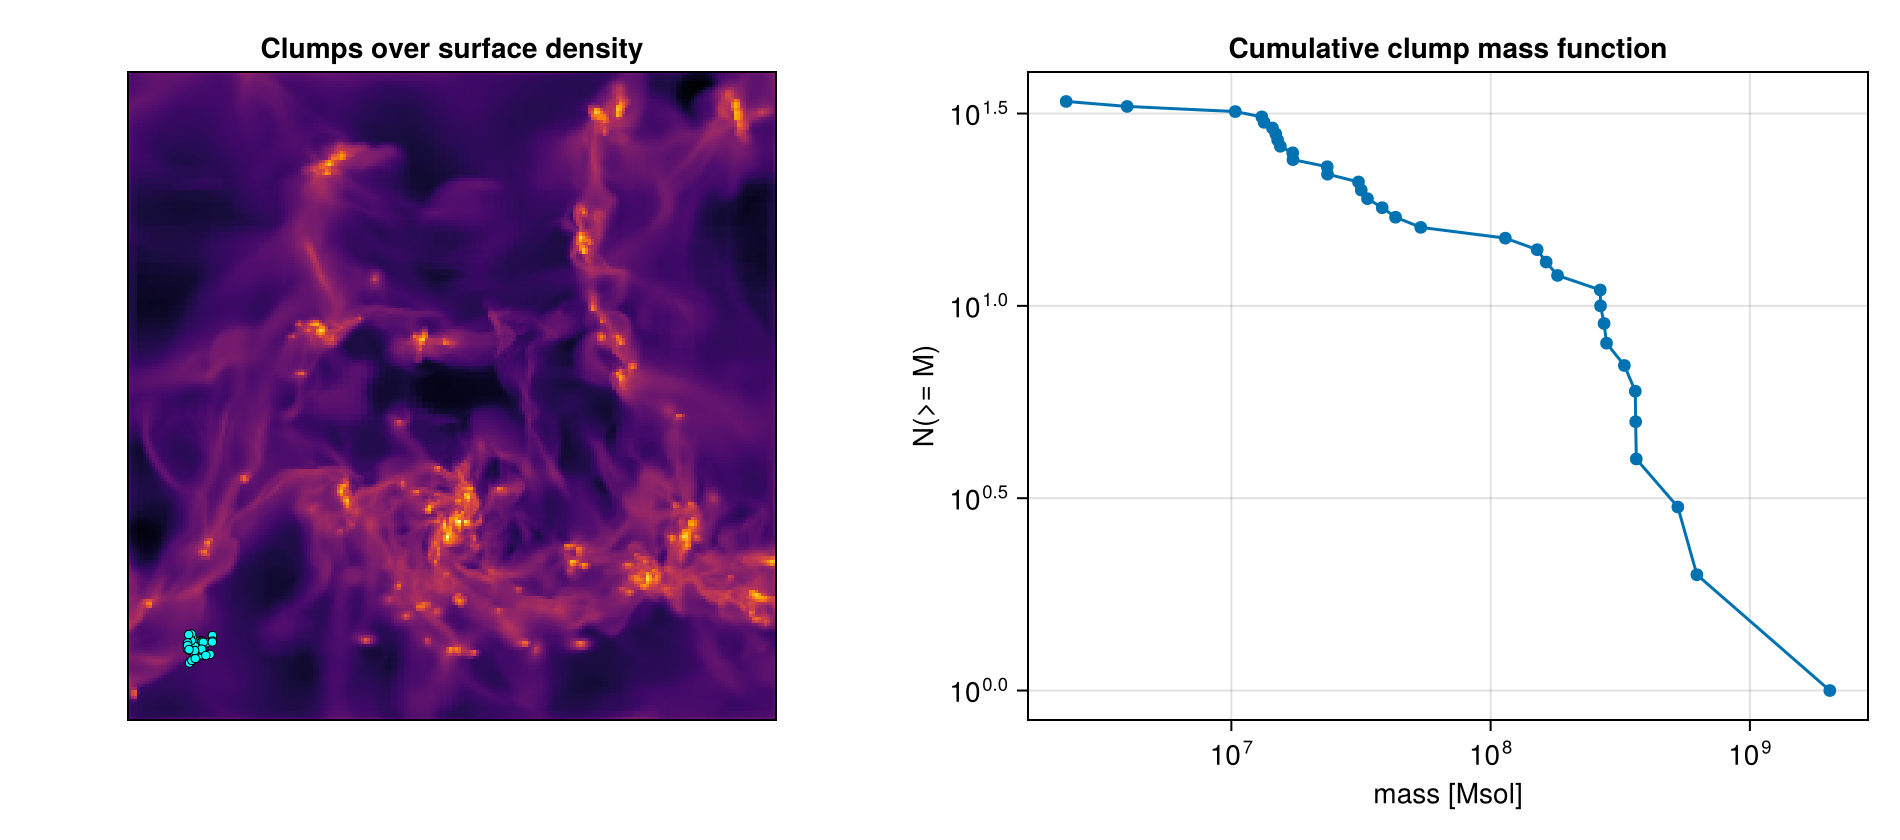

In [10]:
using CairoMakie

bg  = projection(gas, :sd, :Msol_pc2; center=[:bc])
fig = Figure(size=(950, 420))

ax1 = Axis(fig[1,1]; title="Clumps over surface density", aspect=DataAspect())
hidedecorations!(ax1)
heatmap!(ax1, log10.(bg.maps[:sd]'); colormap=:inferno)
coms = [c.com for c in cat]
scatter!(ax1, [c[1] for c in coms], [c[2] for c in coms];
         color=:cyan, markersize=6, strokewidth=0.5, strokecolor=:black)

ax2 = Axis(fig[1,2]; title="Cumulative clump mass function",
           xlabel="mass [Msol]", ylabel="N(>= M)", xscale=log10, yscale=log10)
scatterlines!(ax2, m, Ngt)

fig

A [`ClumpCard`](@ref) runs `clumpfind` inside a [First-Look Report](report.md) (the full catalog is
kept in the card's `data.catalog`):

```julia
report(output; path, cards=[ ClumpCard(:hydro, :rho; threshold=1e2, threshold_unit=:nH,
                                       linking_length=0.2) ])
```

## 2D — a projection map (connected components)

Run it on any [`projection`](@ref) result to segment a map above a threshold:


In [11]:
sd2  = projection(gas, :sd, :Msol_pc2; pxsize=[0.1, :kpc], center=[:bc])
cat2 = clumpfind(sd2, :sd; threshold=50.0, connectivity=8)   # regions >= 50 Msol/pc^2
println("2D regions found : ", length(cat2))
length(cat2) > 0 && println("largest region   : ", cat2[1].n_members, " pixels, mass ",
                            round(cat2[1].mass, sigdigits=4))

[Mera]: 2026-08-03T11:33:28.425



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
ymin::ymax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
zmin::zmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 481^2
Map size: 101 x 101
Pixel size: 99.792 [pc]
Simulation min.: 46.875 [pc]

Available threads: 4
Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)
2D regions found : 

26
largest region   : 1178 pixels, mass 5962.0


`connectivity` is `8` (diagonals count) or `4`. For a surface-density map each region's `mass` is the
exact area-integral `Σ value · pixel_area`; positions are in the map's extent units.

## Multi-scale hierarchy (dendrogram)

A [`Dendrogram`](@ref) finder returns the finest density peaks (local maxima with prominence ≥
`min_delta`) as the catalog's leaf clumps; passing `hierarchy=true` additionally attaches the full
merge [`StructureTree`](@ref) — the level at which leaves join into branches and ultimately roots
(Rosolowsky & Leroy 2008):

```julia
cat  = clumpfind(gas, Dendrogram(:rho; threshold=1e2, threshold_unit=:nH,
                                 linking_length=0.5, min_delta=0.3); hierarchy=true)
tree = cat.tree
length(Mera.leaves(tree))               # finest structures (= the catalog clumps)
r = Mera.roots(tree)[1]                  # a top-level structure
Mera.children(tree, r)                   # its immediate sub-structures
r.n_subtree                              # members in the whole subtree
```

## Density-adaptive finders

Two further finders handle variable-density fields without a single hard threshold:

* [`HDBSCANFinder`](@ref) — a self-contained HDBSCAN\\* (Campello+2013; McInnes+2017): core distances
  define a mutual-reachability metric whose MST is condensed into a cluster hierarchy, and the most
  *stable* clusters (≥ `min_cluster_size`) are extracted. Near parameter-free; points outside any
  stable cluster are labelled noise (dropped).
* [`GraphSegFinder`](@ref) — Felzenszwalb & Huttenlocher (2004) graph segmentation: keeps within-region
  density variation below the between-region contrast, with a single `scale` knob. Near-linear; a fast
  multi-scale deblender.

```julia
cat = clumpfind(gas, HDBSCANFinder(:rho; threshold=1e2, threshold_unit=:nH,
                                   linking_length=2.0, min_cluster_size=20))
cat = clumpfind(gas, GraphSegFinder(:rho; threshold=1e2, threshold_unit=:nH,
                                    linking_length=1.0, scale=5.0))
```

### Finder composition

`deblend` can be **any finder**: a cheap finder establishes connectivity, then the deblend finder
splits each group — e.g. friends-of-friends connectivity refined per-group by HDBSCAN:

```julia
cat = clumpfind(gas, ThresholdFoF(:rho; threshold=1e2, threshold_unit=:nH, linking_length=1.0);
                deblend=HDBSCANFinder(:rho; threshold=1e2, linking_length=0.5, min_cluster_size=30))
```

### Threading

The per-clump statistics/boundedness pass is threaded; `max_threads` (default `Threads.nthreads()`)
caps it, and the result is identical to the serial output regardless of thread count.

### Neighbour backend

Every finder takes a `backend` for its spatial neighbour search: `CellLinkedList` (default),
`HashGrid`, or [`MortonGrid`](@ref) — which visits points along a Z-order (Morton) curve so
spatially-near points are near in memory, improving cache locality on large selections (the same
ordering an out-of-core path needs). All three return identical results; only speed differs.

```julia
cat = clumpfind(gas, ThresholdFoF(:rho; threshold=1e2, threshold_unit=:nH,
                                  linking_length=0.5, backend=MortonGrid))
```

## Phase-space & topology

* [`PhaseSpaceFoF`](@ref) — 6-D friends-of-friends (Rockstar-style; Behroozi+2013): points link only
  when within `linking_length_pos` in space **and** `linking_length_vel` (km/s) in velocity, so
  kinematically distinct populations that overlap spatially — streams, subhaloes, tidal debris —
  separate. Velocities are loaded automatically.
* [`PersistenceFinder`](@ref) — 0-dim persistent homology / ToMATo (Chazal+2013): a peak is kept as a
  separate cluster only if its prominence (peak − merge saddle) reaches `persistence`. Principled,
  parameter-light deblending, robust in crowded fields.

```julia
# kinematically separate two overlapping stellar streams
cat = clumpfind(stars, PhaseSpaceFoF(:mass; threshold=0.0,
                                     linking_length_pos=0.2, linking_length_vel=50.0))
# topological extraction by prominence
cat = clumpfind(gas, PersistenceFinder(:rho; threshold=1e2, threshold_unit=:nH,
                                       linking_length=0.5, persistence=0.3))
```

## Algorithms & implementation

This section documents *how* the finders are implemented and gives the source references. Every finder
shares one pipeline and differs only in the grouping rule, so the algorithms compose from a small set
of building blocks.

### Shared architecture (three layers)

A finder supplies only a grouping rule and inherits statistics, units, boundedness, the catalog and the
hierarchy from the surrounding driver:

1. **Neighbour layer.** A single uniform-grid spatial index answers *"all unique point pairs within the
   linking length `b`"* (and *"neighbours of point `i`"*). Points are hashed into cells of side `b`; a
   27-cell stencil then yields every pair within `b`. Three interchangeable backends produce **identical**
   pairs and differ only in memory/cache behaviour (`backend=`): `HashGrid` (`Dict(cell ⇒ members)`,
   baseline), `CellLinkedList` (head/next linked list per cell — the default, no per-bucket allocation),
   and `MortonGrid` (same pairs, but points are visited in Morton / Z-order so spatial neighbours are
   cache-near). Index build and pair enumeration are ~O(N) at roughly uniform density.
2. **Union-find.** A disjoint-set forest with path-halving merges linked points into connected groups in
   ~O(N·α(N)) and relabels roots to dense ids `1…k`. FoF, graph-segmentation, phase-space FoF and
   HDBSCAN's spanning tree all reuse it.
3. **Finder layer.** Each [`AbstractFinder`](@ref) value type implements `_label(finder, points) →
   (labels, k)` — the *only* algorithm-specific code. The `clumpfind` driver applies the threshold
   pre-cut, runs `_label`, then computes per-clump statistics, boundedness, deblending and the optional
   hierarchy identically for every finder.

!!! note "Works on AMR, uniform grids, particles and Voronoi alike"
    The finders never look at the grid — `clumpfind` first flattens the object into a **point set**:
    every cell (any AMR level) becomes one point at its centre (`getvar(:x,:y,:z)`) carrying its field
    value and its **level-dependent mass and volume** (`getvar(:mass)`/`getvar(:volume)` =
    `ρ·(boxlen/2^level)³`). So a clump's mass, centre of mass, radius and energy budget sum per-cell
    masses that already encode each cell's level — no uniform-cell-size assumption. The neighbour index
    finds *all* pairs within the linking length `b` regardless of how cell sizes or point density vary
    across refinement levels (the 27-cell stencil is exact, not a uniform-grid approximation), so the
    same finder runs unchanged on RAMSES AMR, a uniform grid, SPH/N-body particles, and AREPO Voronoi
    cells. The one thing to set relative to resolution is `b` itself: it is a metric distance, so pick
    a small multiple of the cell size *in the region of interest* (clumps sit at high density → maximum
    refinement, hence internally uniform resolution; e.g. `linking_length ≈ 2·boxlen/2^lmax`). The only
    edge case is a sharp refinement jump *inside* a structure, where a lone coarse cell's centre may lie
    beyond `b` from its fine neighbours — rarely an issue, since clumps are fully refined.

### The finders

- **[`ThresholdFoF`](@ref) — friends-of-friends** (Davis et al. 1985). Link every above-threshold pair
  closer than `linking_length`, then take connected components (within-`b` pairs → union-find). One
  parameter, ~O(N); the classic halo definition and the default.
- **[`DensityWatershed`](@ref) — watershed deblending** (immersion watershed: Vincent & Soille 1991;
  density-maximum/DENMAX lineage: Gelb & Bertschinger 1994; SUBFIND: Springel et al. 2001). Points are
  processed in **descending field order**; each joins the basin of its highest already-processed
  neighbour (steepest ascent), and a point with no higher neighbour starts a new basin (a peak). Where
  basins meet at a **saddle**, `persistence` merges any basin whose prominence (`peak − saddle`) is below
  threshold into the deepest neighbour (a union-find over basins). `persistence=0` is the bare watershed.
- **[`Dendrogram`](@ref) — multi-scale merge tree** (Rosolowsky et al. 2008; cf. `astrodendro`). Takes the
  persistence-watershed basins as **leaves**, measures each adjacent pair's **saddle height** (highest
  field on their shared boundary), and builds the single-linkage tree of the basin-adjacency graph keyed
  by saddle height — **highest saddle merges first**. Returns a [`StructureTree`](@ref) (leaves → branches
  → roots), each node carrying its peak value, merge level and member counts.
- **[`GraphSegFinder`](@ref) — graph segmentation** (Felzenszwalb & Huttenlocher 2004). Neighbour-graph
  edges weighted `|fᵢ − fⱼ|` are merged **cheapest-first** while the weight stays below the per-component
  internal contrast `Int(C) + scale/|C|`. Larger `scale` ⇒ coarser segments; near-linear; for
  smoothly-varying fields with no clean threshold.
- **[`HDBSCANFinder`](@ref) — density-based hierarchical clustering** (HDBSCAN*: Campello et al. 2013;
  McInnes et al. 2017), self-contained: (1) **core distance** = distance to the `min_samples`-th nearest
  neighbour; (2) **mutual-reachability** weights `max(core_i, core_j, d_ij)` and their **minimum spanning
  tree** (Kruskal via union-find); (3) **condense** the tree — at increasing density `λ=1/d`, a split into
  two parts each ≥ `min_cluster_size` spawns two clusters, smaller fragments fall out as noise, and each
  cluster accrues a **stability** `Σ(λ_fall − λ_birth)`; (4) **excess-of-mass** selection keeps a cluster
  iff its stability ≥ that of its sub-clusters. Points in no selected cluster are **noise** (label 0).
- **[`PhaseSpaceFoF`](@ref) — 6-D position+velocity FoF** (Rockstar-style; Behroozi et al. 2013). Links a
  pair only when within `linking_length_pos` in space **and** `linking_length_vel` in velocity (spatial
  index for the position test; velocity test per spatial pair). Separates structures that overlap on the
  sky but differ kinematically (streams, mergers, substructure).
- **[`PersistenceFinder`](@ref) — topological persistence** (ToMATo; Chazal et al. 2013). A superlevel-set
  filtration: densest-first, each point flows by steepest ascent into its highest seen neighbour's basin;
  when basins meet, the **younger** (lower-peak) dies with persistence `peak − saddle` and merges into the
  elder iff that prominence is below `τ`. Surviving basins are the clusters — a parameter-light prominence
  ranking, robust in crowded fields.
- **2-D maps.** On a projection, `clumpfind(proj, :sd; threshold, connectivity)` runs union-find connected
  components of the above-threshold mask (4-/8-connectivity); with deblending, a Meyer-style priority-flood
  watershed from the map's local maxima (Meyer 1994).

### Deblending and gravitational boundedness

- **Peak deblending** (`deblend=true`). Independent of the watershed finders: local field maxima within
  `min_sep` are found (near-duplicate/plateau peaks merged, stronger kept), then every member is assigned
  to its **nearest peak** — splitting merged overlapping clumps post-hoc.
- **Self-boundedness** (the [`Bound`](@ref) validator). Per clump, an energy budget (kinetic + thermal
  [+ magnetic] vs. gravitational) is built. The potential uses `egrav=:tree` (Barnes–Hut tree gravity;
  Barnes & Hut 1986), `:direct` (exact O(N²) below `direct_max`), or `:approx` (`3GM²/5R`). With
  `iterative=true` it performs **SUBFIND-style iterative unbinding** — repeatedly stripping positive-energy
  members until only the self-bound core remains (Springel et al. 2001) — keeping clumps with
  `E_kin + E_therm [+ E_mag] < |E_grav|`; nested bound basins form the substructure tree.

### Validation

[`clump_recovery`](@ref)`(found, truth)` scores a segmentation against per-point ground truth via the
**Adjusted Rand Index** (Hubert & Arabie 1985) plus completeness, purity and bijective merit — the basis
of the data-free [synthetic benchmark](clumpfind_synthetic.md).

### References

- Barnes, J. & Hut, P. 1986, *Nature* 324, 446 — hierarchical (tree) force calculation.
- Behroozi, P. S., Wechsler, R. H. & Wu, H.-Y. 2013, *ApJ* 762, 109 — Rockstar (6-D phase-space halo finder).
- Campello, R. J. G. B., Moulavi, D. & Sander, J. 2013, *PAKDD*, LNCS 7819, 160 — density-based clustering on hierarchical density estimates (HDBSCAN).
- Chazal, F., Guibas, L. J., Oudot, S. Y. & Skraba, P. 2013, *J. ACM* 60(6), 41 — persistence-based clustering (ToMATo).
- Davis, M., Efstathiou, G., Frenk, C. S. & White, S. D. M. 1985, *ApJ* 292, 371 — friends-of-friends.
- Edelsbrunner, H., Letscher, D. & Zomorodian, A. 2002, *Discrete & Comput. Geom.* 28, 511 — topological persistence.
- Felzenszwalb, P. F. & Huttenlocher, D. P. 2004, *Int. J. Computer Vision* 59, 167 — efficient graph-based segmentation.
- Gelb, J. M. & Bertschinger, E. 1994, *ApJ* 436, 467 — DENMAX (density-maximum clump finding).
- Hubert, L. & Arabie, P. 1985, *J. Classification* 2, 193 — Adjusted Rand Index.
- McInnes, L., Healy, J. & Astels, S. 2017, *J. Open Source Software* 2(11), 205 — `hdbscan`.
- Meyer, F. 1994, *Signal Processing* 38, 113 — topographic distance / priority-flood watershed.
- Rosolowsky, E. W., Pineda, J. E., Kauffmann, J. & Goodman, A. A. 2008, *ApJ* 679, 1338 — dendrograms.
- Springel, V., White, S. D. M., Tormen, G. & Kauffmann, G. 2001, *MNRAS* 328, 726 — SUBFIND (gravitational unbinding).
- Vincent, L. & Soille, P. 1991, *IEEE Trans. PAMI* 13, 583 — watersheds by immersion.

## Saving & validation

Persist a catalog (full fidelity — boundedness, nested `subclumps`, the `tree`) and reload it:

```julia
save_clumps("clumps_out100", cat)        # → clumps_out100.jld2
cat = load_clumps("clumps_out100.jld2")
```

[`clump_recovery`](@ref) scores a found segmentation against a known ground truth (per-point labels),
returning the **Adjusted Rand Index**, completeness, purity and bijective merit — the basis of the
validation harness:

```julia
m = clump_recovery(found_labels, true_labels)
m.ari            # ≈ 1 when the finder recovers the input clumps
```

## API

The finder/hierarchy types ([`AbstractFinder`](@ref), [`ThresholdFoF`](@ref),
[`DensityWatershed`](@ref), [`Dendrogram`](@ref), [`GraphSegFinder`](@ref), [`HDBSCANFinder`](@ref),
[`PhaseSpaceFoF`](@ref), [`PersistenceFinder`](@ref), [`StructureTree`](@ref), [`StructureNode`](@ref))
are documented in the [API reference](api.md#Types).

```@docs
clumpfind
clump_massfunction
clump_recovery
clumptable
save_clumps
load_clumps
ClumpCard
synthetic_clumps
save_synthetic_clumps
load_synthetic_clumps
```